In [1]:
import torch 
import torch.nn as nn 
import torch.optim as optim 
import torch.nn.functional as F 
from torch.utils.data import DataLoader 
import torchvision.datasets as datasets 
import torchvision.transforms as transforms 


In [2]:
# simple nn
class NN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NN, self).__init__()
        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, num_classes)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x 


$$
n_{out} = \left\lfloor\frac{n_{in}+2p-k}{s}\right\rfloor +1
$$
$$
n_{in} \text{: number of input features  }\\
n_{out} \text{ : number of output features }\\
\text{k : convolution kernel size }\\
\text{p : convolution padding size }\\
\text{s : convolution stride size 
}
$$

In [3]:
# a simple cnn
# class CNN(nn.Module):
#     def __init__(self, in_channels =1 , num_classes =10 ):
#         super(CNN, self).__init__()
#         self.conv1 = nn.Conv2d(in_channels= 1, out_channels= 8, kernel_size= (3,3), stride=(1,1), padding=(1,1))  # this is same convolution layer has input and op equal
#         self.pool = nn.MaxPool2d(kernel_size=(2,2), stride = (2,2))  #same formula halves the size
#         self.conv2 = nn.Conv2d(in_channels= 8, out_channels= 16, kernel_size= (3,3), stride=(1,1), padding=(1,1))  # this is same convolution layer has input and op equal
        
#         #dummy forward pass
        
#         self.fc1 = nn.Linear(16*7*7, num_classes)
        
#     def forward(self,x):
#         x = F.relu(self.conv1(x))
#         x = self.pool(x) 
#         x = F.relu(self.conv2(x))
#         x= self.pool(x) 
#         x = x.reshape(x.shape[0], -1)
#         x = self.fc1(x)
        
#         return x 
    


cleaner version to make a cnn

##  always be careful of the highlight colors if something feels off there is an error

In [6]:
class CNN(nn.Module):
    def __init__(self, in_channels= 1, num_classes = 10):
        super(CNN, self).__init__()
        
        #part 1 : define the feature extraction layer 
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels = 1, out_channels =  8, kernel_size = (3,3), stride = (1,1), padding = (1,1)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = (2,2), stride = (2,2)),
            nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = (3,3), stride = (1,1), padding = (1,1))
            , nn.ReLU(),
            nn.MaxPool2d(kernel_size = (2,2), stride = (2,2))
        )
        
        #part 2 the dummy forward pass to get the flattened size 
        
        dummy_input = torch.randn(1,1,28,28)
        dummy_output = self.feature_extractor(dummy_input)
        flattened_size = dummy_output.numel() 
        
        self.classifier = nn.Linear(flattened_size, num_classes)
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.reshape(x.shape[0], -1)   # flatten the output tensor for the classifier, -1 tells pytorch to infer the dimension from the other dimensions
        x = self.classifier(x)
        return x 

In [7]:
model = CNN()

x = torch.randn(64,1,28,28)
print(x.shape)
print(model(x).shape)

torch.Size([64, 1, 28, 28])
torch.Size([64, 10])


In [8]:
#set device 
device  =  torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [9]:
#hyper parameters
in_channels = 1 
num_classes = 10 
learning_rate = 0.001
batch_size = 64 
num_epoch = 5

In [10]:
#load data 
train_dataset = datasets.MNIST(root = 'datasets/', train = True, transform = transforms.ToTensor(), download = True)
train_loader = DataLoader(dataset= train_dataset, batch_size= batch_size, shuffle = True)
test_dataset = datasets.MNIST(root = 'datasets/', train = False, transform= transforms.ToTensor(), download = True)
test_loader = DataLoader(dataset= test_dataset, batch_size= batch_size, shuffle = True)

In [11]:
#initialize network 
model = CNN().to(device)

#loss and optimizer 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [ ]:
def check_accuracy(loader, model):
    if loader.dataset.train:
        print("checking accuracy on training data")
    else: 
        print("Checking accuracy on test data")
    
    num_correct = 0
    num_samples = 0
    model.eval()
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device = device)
            y = y.to(device = device)
            # x = x.reshape(x.shape[0], -1)              #reshaped in forward pass so no need to reshape here 
            
            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)
            # print(num_correct, num_samples)
        
    accuracy = float(num_correct)/float(num_samples)*100    
    print(f'Got {num_correct}/ {num_samples} with accuracy {accuracy:.2f} ')
    model.train()  
    return accuracy
    



checking accuracy on training data
Got 5421/ 60000 with accuracy 9.04 
Checking accuracy on test data
Got 892/ 10000 with accuracy 8.92 


8.92

### The below check accuracy is done to 
- establishing a sanity check and baseline
- verify that learning is happening 
- as it helps debugging isolation problems:  
    If our model's accuracy doesn't improve after the first epoch, having the baseline check helps us isolate the problem.
    If the initial accuracy was ~10% but it's still ~10% after one epoch, the problem is likely in our training loop (e.g., we forgot optimizer.step() or loss.backward()).
    If the initial accuracy was already strange (e.g., 0%), the problem is likely in our model definition, data loading, or accuracy function.

In [ ]:

#sanity check for the untrained model 
check_accuracy(train_loader, model)
check_accuracy(test_loader, model)




In [13]:
#list to store metrics 
train_losses = []
train_accuracies = []
test_accuracies = []


#train network 
for epoch in range(num_epoch):
    for batch_idx, (data,targets) in enumerate (train_loader):
        #get data to cuda if possible 
        data = data.to(device = device)
        targets = targets.to(device = device)
        
        #forward 
        scores = model(data)
        loss = criterion(scores, targets)
        # train_losses.append(float(loss))         #to print the loss need to convert it to float
        train_losses.append(loss.item())
        #backward 
        optimizer.zero_grad()
        loss.backward()
        
        #gradient descent or adam step 
        optimizer.step() 
        
    
    #check accuracy at the end of each epoch 
    print(f'--Epoch {epoch+1}/{num_epoch}--')
    train_acc = check_accuracy(train_loader, model)
    test_acc = check_accuracy(test_loader, model)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)


--Epoch 1/5--
checking accuracy on training data
Got 57879/ 60000 with accuracy 96.47 
Checking accuracy on test data
Got 9671/ 10000 with accuracy 96.71 
--Epoch 2/5--
checking accuracy on training data
Got 58646/ 60000 with accuracy 97.74 
Checking accuracy on test data
Got 9786/ 10000 with accuracy 97.86 
--Epoch 3/5--
checking accuracy on training data
Got 59056/ 60000 with accuracy 98.43 
Checking accuracy on test data
Got 9833/ 10000 with accuracy 98.33 
--Epoch 4/5--
checking accuracy on training data
Got 59151/ 60000 with accuracy 98.58 
Checking accuracy on test data
Got 9833/ 10000 with accuracy 98.33 
--Epoch 5/5--
checking accuracy on training data
Got 59233/ 60000 with accuracy 98.72 
Checking accuracy on test data
Got 9833/ 10000 with accuracy 98.33 


In [14]:
print(train_losses) 
print()

[2.3035855293273926, 2.3029589653015137, 2.318754196166992, 2.301126718521118, 2.27982234954834, 2.2925257682800293, 2.3091001510620117, 2.27425479888916, 2.284736394882202, 2.2630176544189453, 2.2625608444213867, 2.2473740577697754, 2.280909776687622, 2.2495996952056885, 2.2462735176086426, 2.2301125526428223, 2.249300241470337, 2.243485689163208, 2.211515188217163, 2.1730968952178955, 2.2179670333862305, 2.1607253551483154, 2.183739185333252, 2.146432876586914, 2.1724042892456055, 2.1247148513793945, 2.13734769821167, 2.078976631164551, 2.0928399562835693, 2.0251026153564453, 2.00661301612854, 1.9851746559143066, 2.0140273571014404, 2.0160632133483887, 1.9230389595031738, 1.8861327171325684, 1.869504451751709, 1.8258205652236938, 1.9427926540374756, 1.8688716888427734, 1.8634246587753296, 1.7270779609680176, 1.7624003887176514, 1.6844614744186401, 1.6414034366607666, 1.5893192291259766, 1.6952155828475952, 1.5427271127700806, 1.4976897239685059, 1.4136152267456055, 1.4893776178359985

In [15]:
print(train_accuracies)

[96.465, 97.74333333333334, 98.42666666666666, 98.585, 98.72166666666666]


In [16]:
import matplotlib.pyplot as plt

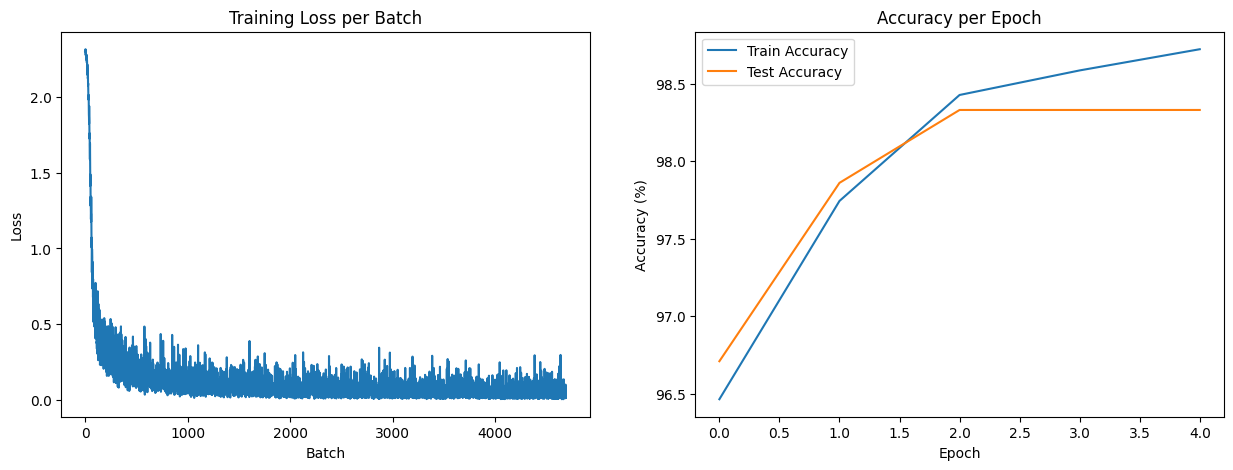

In [17]:
# Add a new code cell
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Training Loss
ax1.plot(train_losses)
ax1.set_title("Training Loss per Batch")
ax1.set_xlabel("Batch")
ax1.set_ylabel("Loss")

# Plot Training & Testing Accuracy
ax2.plot(train_accuracies, label="Train Accuracy")
ax2.plot(test_accuracies, label="Test Accuracy")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()

plt.show()

the above plot shows the sign of overfitting after 2 epoch as the training accuracy keeps on increasing but the test accuracy pleatues (flattens)

- Implement Early Stopping: For future runs, we can implement a mechanism to monitor the test (or validation) accuracy and stop the training automatically when it stops improving for a certain number of epochs. This saves time and prevents further overfitting.
- Consider Regularization: If we wanted to push the performance even further or train for more epochs, we can introduce regularization techniques like Dropout layers or Weight Decay in your optimizer. These techniques are designed to combat overfitting and can help close the gap between training and testing accuracy.
- Hyperparameter Tuning: While the results are good, we can experiment with different learning rates or a more complex model architecture to see if we can push the plateau of the test accuracy even higher.

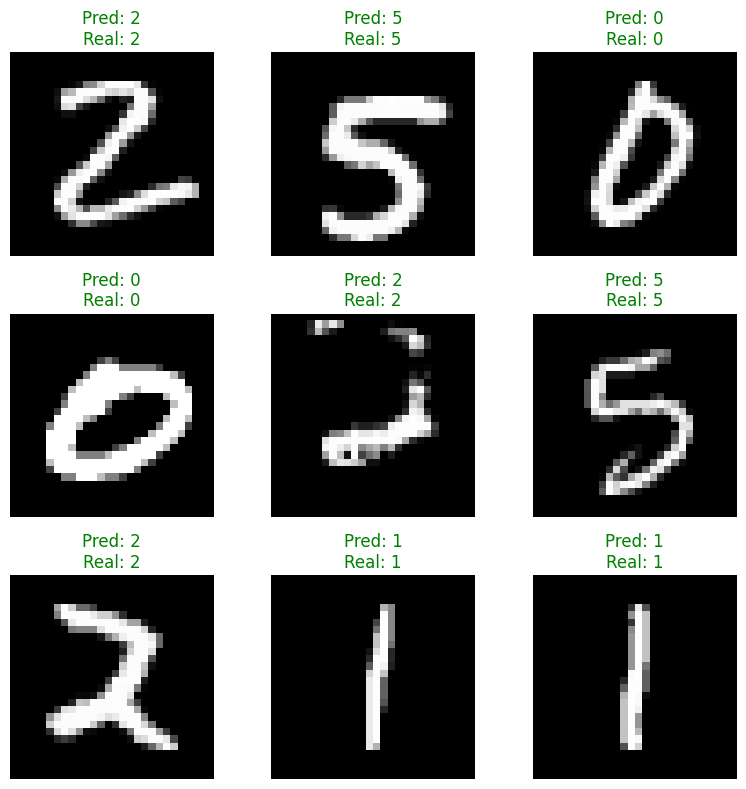

In [18]:
# Add a new code cell
def plot_predictions(loader, model, num_images=9):
    """
    Plots a grid of images with their predicted and actual labels.
    """
    model.eval() # Set model to evaluation mode
    
    # Get a single batch of test data
    images, labels = next(iter(loader))
    images_to_plot = images[:num_images].to(device=device)
    labels_to_plot = labels[:num_images]

    # Get predictions
    with torch.no_grad():
        scores = model(images_to_plot)
        _, predictions = scores.max(1)

    # Move data to CPU for plotting
    images_to_plot = images_to_plot.cpu()
    predictions = predictions.cpu()
    
    # Create a grid for plotting
    # We assume a square grid, so num_images should be a perfect square like 9 or 16
    grid_size = int(num_images**0.5)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))
    axes = axes.flatten()

    for i in range(num_images):
        ax = axes[i]
        # Squeeze to remove channel dimension (1, 28, 28) -> (28, 28)
        img = images_to_plot[i].squeeze()
        
        ax.imshow(img, cmap='gray')
        pred_label = predictions[i].item()
        true_label = labels_to_plot[i].item()
        
        # Set title color to green for correct, red for incorrect
        color = "green" if pred_label == true_label else "red"
        ax.set_title(f"Pred: {pred_label}\nReal: {true_label}", color=color)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    model.train() # Set model back to training mode

# Call the function to display the predictions
plot_predictions(test_loader, model)

gemini review : 
Yes, your implementation of a simple Convolutional Neural Network (CNN) is quite correct and demonstrates a perspicuous (\pər-ˈspi-kyə-wəs\ clearly expressed and easily understood) grasp of fundamental PyTorch concepts. It is a well-structured and functional piece of code for classifying the MNIST dataset.

Let's elucidate (\i-ˈlü-sə-ˌdāt\ to make clear or easy to understand) why your implementation is correct by examining its key components:

1. Model Architecture (CNN class)
The architecture you've defined is a paradigmatic (\per-ə-dig-ˈma-tik, -dəg-\ serving as a typical example of something) example of a simple CNN for image classification.

Convolutional Layers:

self.conv1: You correctly use padding=(1,1) with kernel_size=(3,3) and stride=(1,1). This configuration results in a "same" convolution, meaning the output spatial dimensions (28x28) are identical to the input (28x28). This is a common technique to preserve spatial information.

self.conv2: This layer correctly takes the 8 output channels from conv1 as its input channels and applies another "same" convolution.

Pooling Layer:

self.pool: The MaxPool2d layer with a kernel size and stride of 2 correctly halves the spatial dimensions of the feature maps.

After conv1, the shape is (batch, 8, 28, 28). After the first pool, it becomes (batch, 8, 14, 14).

After conv2, the shape is (batch, 16, 14, 14). After the second pool, it becomes (batch, 16, 7, 7).

Fully Connected Layer:

self.fc1: The input size 16*7*7 is calculated perfectly. It corresponds to flattening the output of the final pooling layer (16 channels, 7x7 spatial dimensions). This prepares the data for the final linear classification step.

Forward Pass:

The sequence of operations (conv -> relu -> pool) is standard and correctly implemented.

The x.reshape(x.shape[0], -1) call is the correct way to flatten the tensor before passing it to the fully connected layer.

2. Training and Evaluation
Your training and evaluation logic adheres to best practices, showing a trenchant (\ˈtren-chənt\ vigorous or incisive in expression or style) understanding of the PyTorch workflow.

Data Handling: The use of torchvision.datasets.MNIST and DataLoader is the standard, efficient way to manage data.

Loss Function & Optimizer: Your choice of nn.CrossEntropyLoss is appropriate for this multi-class classification problem as it expects raw, unnormalized scores (logits) from the model. optim.Adam is a robust and popular optimizer.

Training Loop: The training loop is a veritable (\ˈver-ə-tə-bəl\ being in fact the thing named and not false) textbook example:

Move data and targets to the correct device.

Perform a forward pass to get scores.

Compute the loss.

Zero the gradients (optimizer.zero_grad()).

Perform backpropagation (loss.backward()).

Update the weights (optimizer.step()).

Accuracy Check Function: The check_accuracy function is particularly well-implemented.

model.eval(): You correctly switch the model to evaluation mode. This is a crucial step that disables layers like Dropout or BatchNorm during inference (though your model doesn't have them, it is a prophylactic (\prō-fə-ˈlak-tik\ intended to prevent disease) and essential habit).

torch.no_grad(): Using this context manager correctly disables gradient computation, which saves memory and speeds up the process.

model.train(): You astutely remember to switch the model back to training mode after evaluation. This is a common pitfall that you have successfully avoided.

The final accuracy of ~96.6% after a single epoch is a plausible and good result for this architecture on MNIST, providing further verisimilitude (\ver-ə-sə-ˈmi-lə-ˌtüd, -ˌtüd\ the quality of seeming real) to the correctness of your code.